In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [ ]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No" :0
})

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

In [ ]:
cat_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [ ]:
df['Attrition'].dtype

dtype('int64')

In [ ]:
ohe = OneHotEncoder(drop = 'first', sparse_output=False)
encoded  = ohe.fit_transform(df[cat_cols])

In [ ]:
encoded_df = pd.DataFrame( encoded,
                          columns = ohe.get_feature_names_out(cat_cols)) # convert to the data frame

In [ ]:
num_df = df.drop(columns = cat_cols)

updated_df = pd.concat(
    [num_df.reset_index(drop=True),
     encoded_df.reset_index(drop=True)],
    axis=1
)

In [ ]:
updated_df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,49,0,279,8,1,1,2,3,61,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,37,1,1373,2,2,1,4,4,92,2,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,33,0,1392,3,4,1,5,4,56,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,27,0,591,2,1,1,7,1,40,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
updated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   int64  
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   int64  
 3   DistanceFromHome                   1470 non-null   int64  
 4   Education                          1470 non-null   int64  
 5   EmployeeCount                      1470 non-null   int64  
 6   EmployeeNumber                     1470 non-null   int64  
 7   EnvironmentSatisfaction            1470 non-null   int64  
 8   HourlyRate                         1470 non-null   int64  
 9   JobInvolvement                     1470 non-null   int64  
 10  JobLevel                           1470 non-null   int64  
 11  JobSatisfaction                    1470 non-null   int64

In [ ]:
updated_df["Attrition"].dtype

dtype('int64')

In [ ]:
X = updated_df.drop("Attrition", axis=1)
y = updated_df["Attrition"]

<Axes: xlabel='Attrition', ylabel='count'>

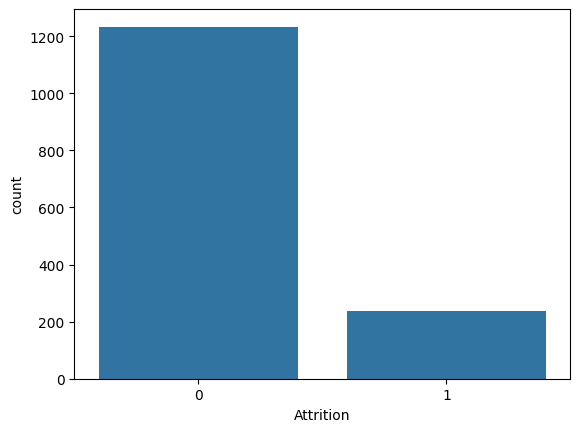

In [ ]:
sns.countplot(x="Attrition", data=df)

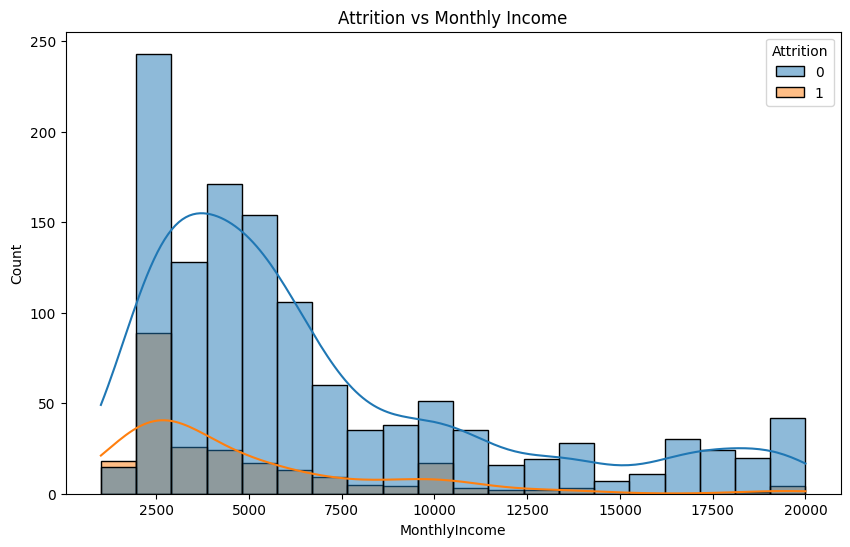

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="MonthlyIncome",
    hue="Attrition",
    kde=True
)

plt.title("Attrition vs Monthly Income")
plt.show()

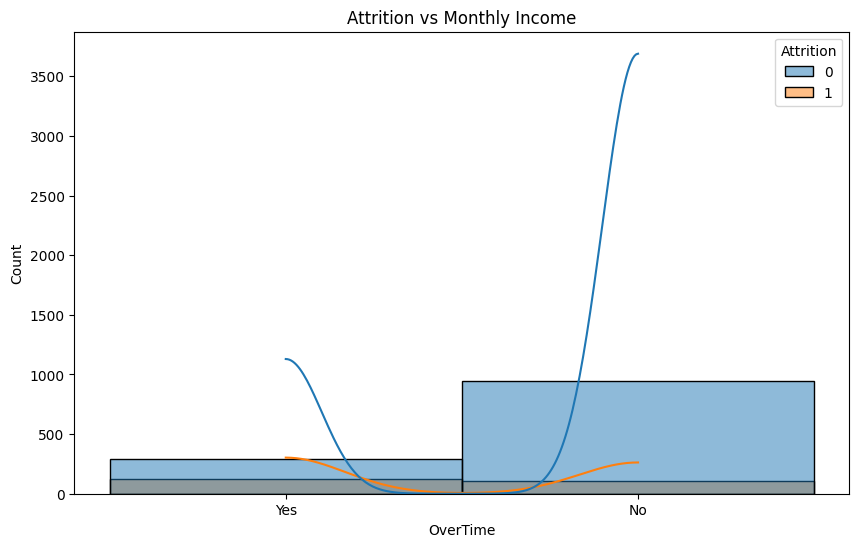

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="OverTime",
    hue="Attrition",
    kde=True
)

plt.title("Attrition vs Monthly Income")
plt.show()

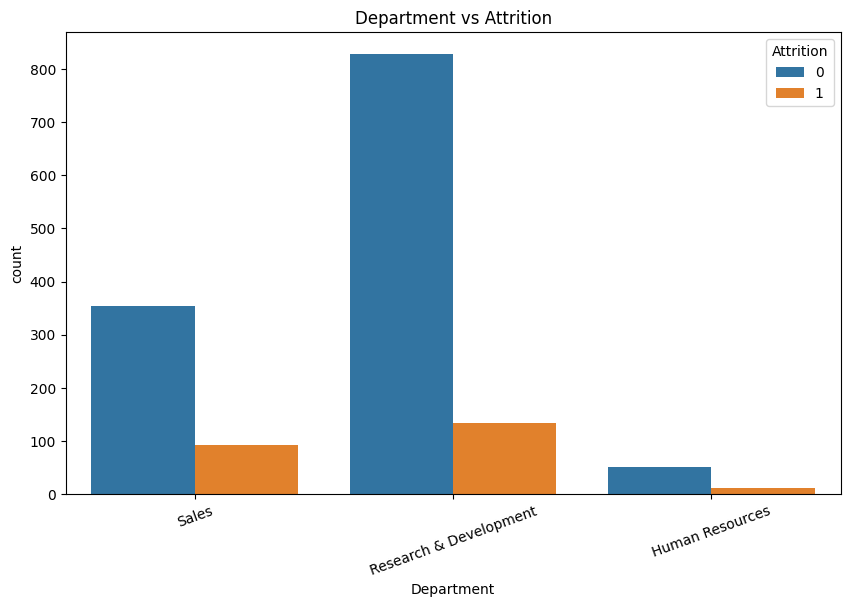

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.xticks(rotation=20)
plt.title("Department vs Attrition")
plt.show()

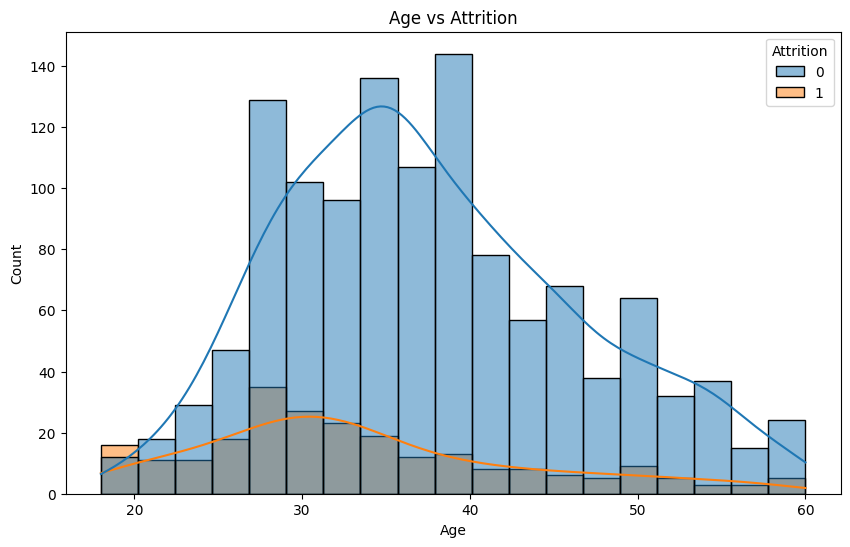

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    kde=True
)

plt.title("Age vs Attrition")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ANN-DATASET AND DATALOADER

In [ ]:
import torch
import torch.nn as nn

In [ ]:

print(type(X_train_scaled))# numpy array
print(type(y_train))# pandas series

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

In [ ]:
from torch.utils.data import TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
from torch.utils.data import DataLoader

train_Loader =  DataLoader(train_dataset , batch_size =32, shuffle = True)
test_Loader =  DataLoader(test_dataset , batch_size =32, shuffle = False)

In [ ]:
df.shape

(1470, 35)

In [ ]:


class ANNModel(nn.Module):

    def __init__(self, input_size):

        super(ANNModel, self).__init__()

        self.model = nn.Sequential(
          nn.Linear(input_size, 64),
          nn.ReLU(),

          nn.Linear(64, 32),
          nn.ReLU(),
          nn.Linear(32, 16),
          nn.ReLU(),

          nn.Linear(16, 1)
      )
    def forward(self, x):

        return self.model(x)

In [ ]:
input_size = X_train.shape[1]

model = ANNModel(input_size)

In [ ]:
print(model)

ANNModel(
  (model): Sequential(
    (0): Linear(in_features=47, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


##Evaluationn Function


In [ ]:
import torch.optim as optim
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

##Training ANN

In [ ]:
print(y_train_tensor.shape)
print(torch.unique(y_train_tensor))

torch.Size([1176, 1])
tensor([0., 1.])


In [ ]:
training_losses = []
val_losses = []

epochs = 100
best_val_loss = float('inf')

for epoch in range(epochs):

    # Training
    model.train()

    running_train_loss = 0.0

    for xb, yb in train_Loader:

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_Loader)

    training_losses.append(epoch_train_loss)

    # Validation
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_Loader:

            outputs = model(xb)

            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_Loader)

    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

Epoch [1/100] Train Loss: 0.4331 Val Loss: 0.3396
Epoch [2/100] Train Loss: 0.3830 Val Loss: 0.3318
Epoch [3/100] Train Loss: 0.3521 Val Loss: 0.3209
Epoch [4/100] Train Loss: 0.3272 Val Loss: 0.3117
Epoch [5/100] Train Loss: 0.3130 Val Loss: 0.3111
Epoch [6/100] Train Loss: 0.2919 Val Loss: 0.3135
Epoch [7/100] Train Loss: 0.2723 Val Loss: 0.3135
Epoch [8/100] Train Loss: 0.2514 Val Loss: 0.3107
Epoch [9/100] Train Loss: 0.2337 Val Loss: 0.3108
Epoch [10/100] Train Loss: 0.2166 Val Loss: 0.3220
Epoch [11/100] Train Loss: 0.1985 Val Loss: 0.3276
Epoch [12/100] Train Loss: 0.1855 Val Loss: 0.3345
Epoch [13/100] Train Loss: 0.1684 Val Loss: 0.3516
Epoch [14/100] Train Loss: 0.1528 Val Loss: 0.3675
Epoch [15/100] Train Loss: 0.1380 Val Loss: 0.3774
Epoch [16/100] Train Loss: 0.1249 Val Loss: 0.3965
Epoch [17/100] Train Loss: 0.1116 Val Loss: 0.4303
Epoch [18/100] Train Loss: 0.0959 Val Loss: 0.4501
Epoch [19/100] Train Loss: 0.0844 Val Loss: 0.4814
Epoch [20/100] Train Loss: 0.0778 Val Lo

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for xb, yb in test_Loader:

        logits = model(xb)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).float()

        correct += (preds == yb).sum().item()

        total += yb.size(0)

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 84.01%


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for xb, yb in test_Loader:

        logits = model(xb)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(yb.cpu().numpy())

cm = confusion_matrix(
    np.array(all_labels),
    np.array(all_preds)
)

print(cm)

[[234  21]
 [ 26  13]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds
    )
)

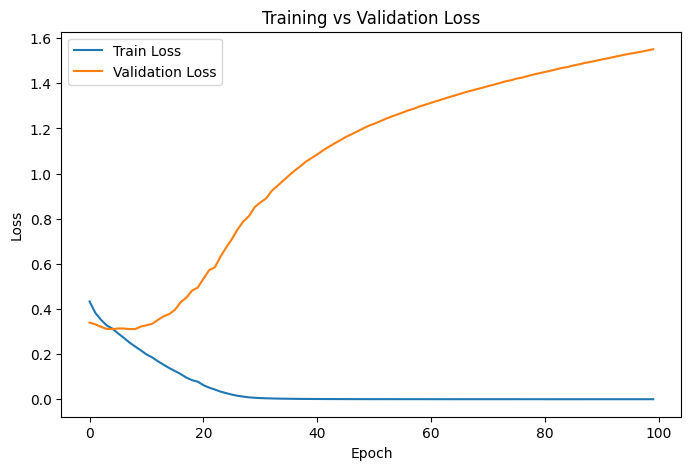

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(training_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [ ]:
torch.load("best_model.pt")

OrderedDict([('model.0.weight',
              tensor([[ 0.1074, -0.0401, -0.0123,  ..., -0.0706, -0.1537,  0.0176],
                      [-0.0756,  0.0288, -0.0283,  ..., -0.1335,  0.0905,  0.1808],
                      [ 0.0411, -0.0136, -0.1195,  ..., -0.0245,  0.0841, -0.2007],
                      ...,
                      [-0.0479,  0.1185, -0.0453,  ...,  0.1138, -0.0024, -0.0558],
                      [ 0.0770, -0.0497,  0.0161,  ..., -0.1352, -0.1969,  0.1063],
                      [ 0.1275, -0.1179,  0.1016,  ...,  0.0944,  0.0187, -0.2819]])),
             ('model.0.bias',
              tensor([-0.0356,  0.1018,  0.1636,  0.0518,  0.0518,  0.1253,  0.1757,  0.0299,
                      -0.0715,  0.1659, -0.1159,  0.0314, -0.0058,  0.0117,  0.0002,  0.1077,
                       0.0482,  0.2046,  0.1591, -0.0561,  0.0294,  0.1071,  0.2104,  0.0997,
                      -0.0854,  0.1151,  0.0442,  0.0379,  0.0077,  0.0854, -0.0878, -0.0172,
                      -0.031

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

#Evaluation for Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8775510204081632

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294


Confusion Matrix:
[[254   1]
 [ 35   4]]


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

              Feature  Importance
11      MonthlyIncome    0.071784
46       OverTime_Yes    0.061896
1           DailyRate    0.054603
5      EmployeeNumber    0.049249
0                 Age    0.048570
19  TotalWorkingYears    0.047738
12        MonthlyRate    0.047392
7          HourlyRate    0.041425
2    DistanceFromHome    0.040048
22     YearsAtCompany    0.036038


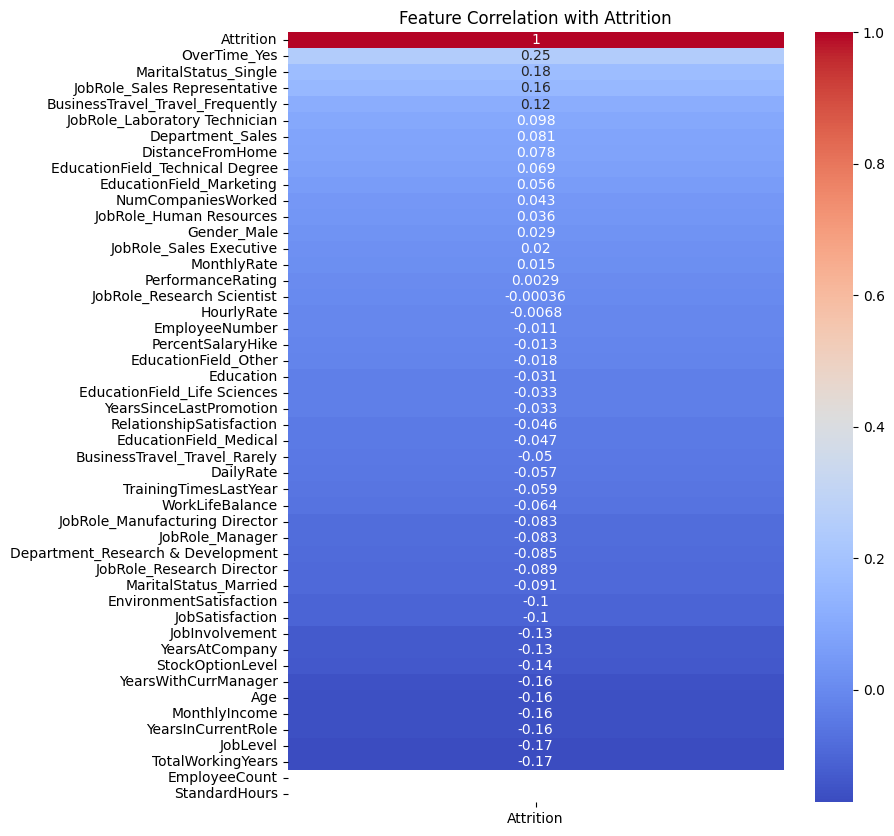

In [ ]:
corr_with_target = updated_df.corr()['Attrition'].sort_values(
    ascending=False
)

plt.figure(figsize=(8, 10))

sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation with Attrition')
plt.show()

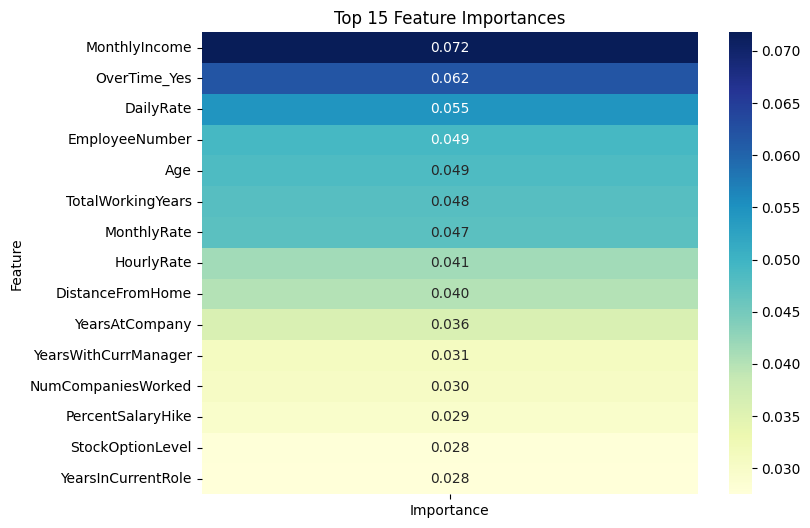

In [ ]:


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

plt.figure(figsize=(8, 6))

sns.heatmap(
    feature_importance.set_index('Feature'),
    annot=True,
    cmap='YlGnBu',
    fmt='.3f'
)

plt.title('Top 15 Feature Importances')
plt.show()

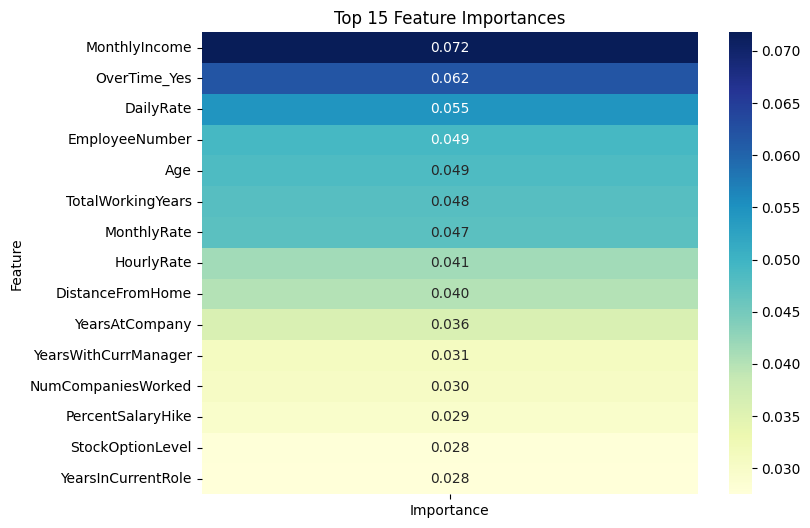

In [ ]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

plt.figure(figsize=(8, 6))

sns.heatmap(
    feature_importance.set_index('Feature'),
    annot=True,
    cmap='YlGnBu',
    fmt='.3f'
)

plt.title('Top 15 Feature Importances')
plt.show()

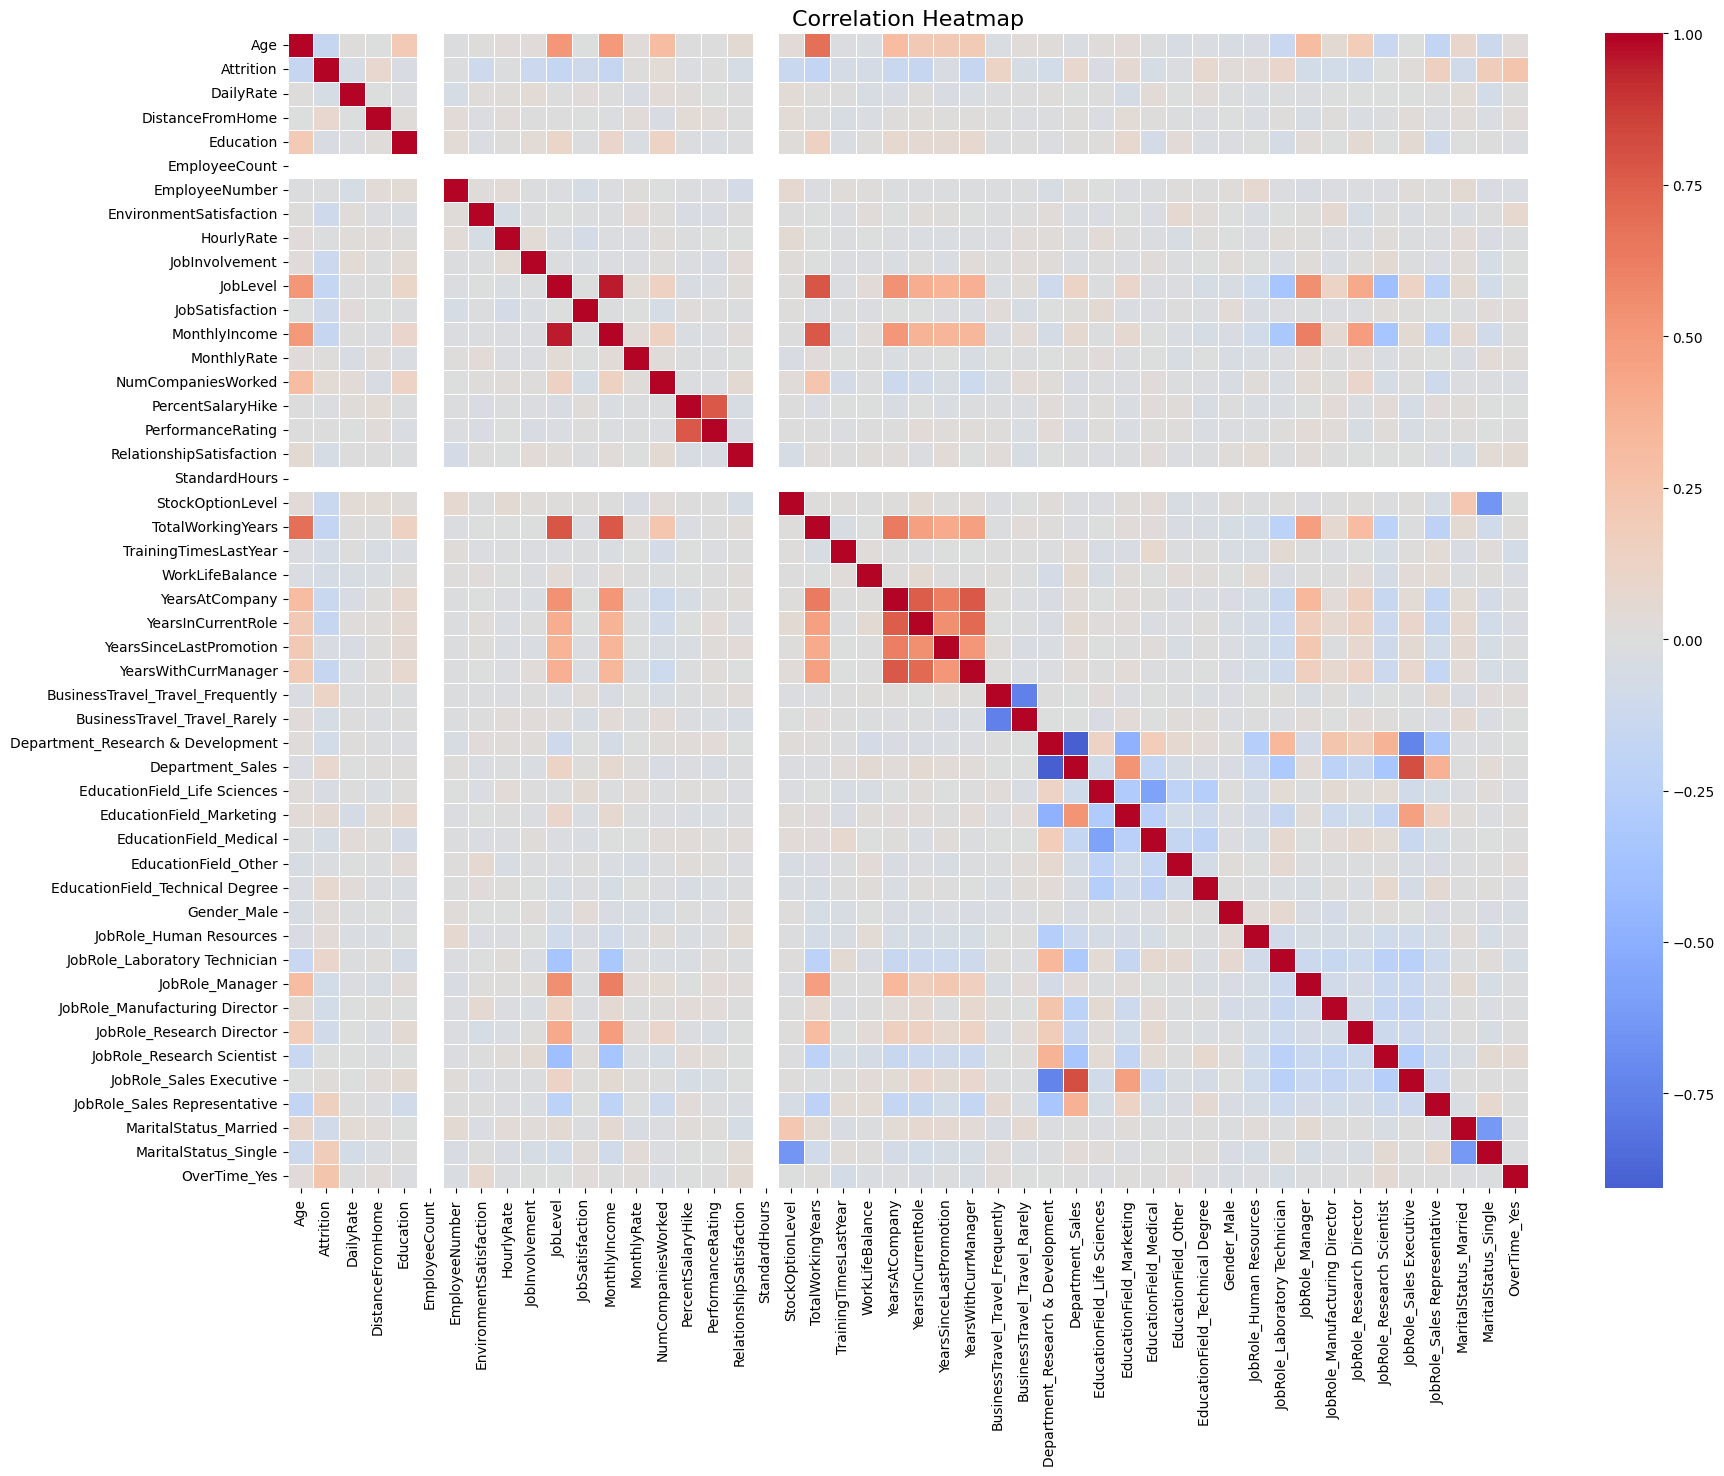